#  Food Ingredient Safety Classifier
### Deep Learning NLP Project — Binary Classification (Contains Allergen / Does Not Contain)
**Stack:** Python | TensorFlow/Keras | Hugging Face Transformers | Scikit-learn | Pandas

---
**Project Goal:** Predict whether a food product **Contains** or **Does Not Contain** allergens based on its ingredients using Deep Learning (LSTM + DistilBERT fine-tuning).

**Dataset:** Food Ingredients and Allergens (399 samples)

---

##  Step 1: Install & Import Libraries

In [ ]:
# Install required libraries (run once)
#%pip install transformers datasets scikit-learn pandas numpy matplotlib seaborn tensorflow torch -q
#%pip install "accelerate>=1.1.0" -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Embedding, LSTM, Bidirectional,
    GlobalAveragePooling1D, BatchNormalization, Concatenate
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Transformers (Hugging Face)
import torch
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)
from torch.utils.data import Dataset as TorchDataset

print('✅ All libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')
print(f'PyTorch version: {torch.__version__}')
print(f'GPU Available: {torch.cuda.is_available()}')

✅ All libraries imported successfully!
TensorFlow version: 2.21.0
PyTorch version: 2.11.0+cpu
GPU Available: False


---
##  Step 2: Load & Explore the Dataset (EDA)

In [3]:
# Load dataset — update path if needed
df = pd.read_csv('C:\\Users\\anind\\Desktop\\ML\\food\\food_ingredients_and_allergens.csv')

print('Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())
df.head(10)

Shape: (399, 7)

Column Names: ['Food Product', 'Main Ingredient', 'Sweetener', 'Fat/Oil', 'Seasoning', 'Allergens', 'Prediction']


,Food Product,Main Ingredient,Sweetener,Fat/Oil,Seasoning,Allergens,Prediction
0,Almond Cookies,Almonds,Sugar,Butter,Flour,"Almonds, Wheat, Dairy",Contains
1,Almond Cookies,Almonds,Sugar,Butter,Flour,"Almonds, Wheat, Dairy",Contains
2,Chicken Noodle Soup,Chicken broth,NaN,NaN,Salt,"Chicken, Wheat, Celery",Contains
3,Chicken Noodle Soup,Chicken broth,NaN,NaN,Salt,"Chicken, Wheat, Celery",Contains
4,Cheddar Cheese,Cheese,NaN,NaN,Salt,Dairy,Contains
5,Ranch Dressing,Buttermilk,Sugar,Vegetable oil,"Garlic, herbs",Dairy,Contains
6,Caramel Popcorn,Popcorn,Sugar,Butter,Salt,Dairy,Contains
7,Caesar Salad,Romaine lettuce,NaN,Olive oil,Parmesan cheese,Dairy,Contains
8,Caesar Wrap,Grilled chicken,NaN,Caesar dressing,"Lettuce, Parmesan cheese",Dairy,Contains
9,Strawberry Smoothie,Strawberries,Honey,"Yogurt (milk, cultures)",NaN,Dairy,Contains


In [4]:
# Data types and missing values
print('Data Info:')
print(df.info())
print('\nMissing Values:')
print(df.isnull().sum())
print('\nTarget Distribution:')
print(df['Prediction'].value_counts())

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Food Product     399 non-null    str  
 1   Main Ingredient  399 non-null    str  
 2   Sweetener        119 non-null    str  
 3   Fat/Oil          341 non-null    str  
 4   Seasoning        379 non-null    str  
 5   Allergens        251 non-null    str  
 6   Prediction       398 non-null    str  
dtypes: str(7)
memory usage: 46.9 KB
None

Missing Values:
Food Product         0
Main Ingredient      0
Sweetener          280
Fat/Oil             58
Seasoning           20
Allergens          148
Prediction           1
dtype: int64

Target Distribution:
Prediction
Contains            255
Does not contain    143
Name: count, dtype: int64


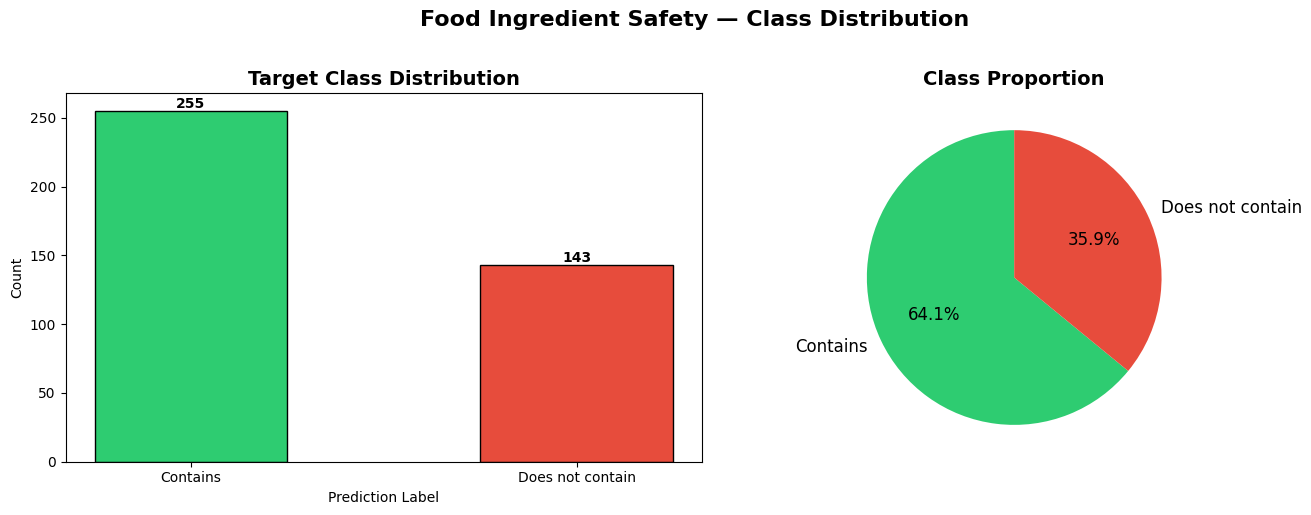

✅ Plot saved as class_distribution.png


In [5]:
# Visualize target class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = df['Prediction'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Target Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Prediction Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Food Ingredient Safety — Class Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved as class_distribution.png')

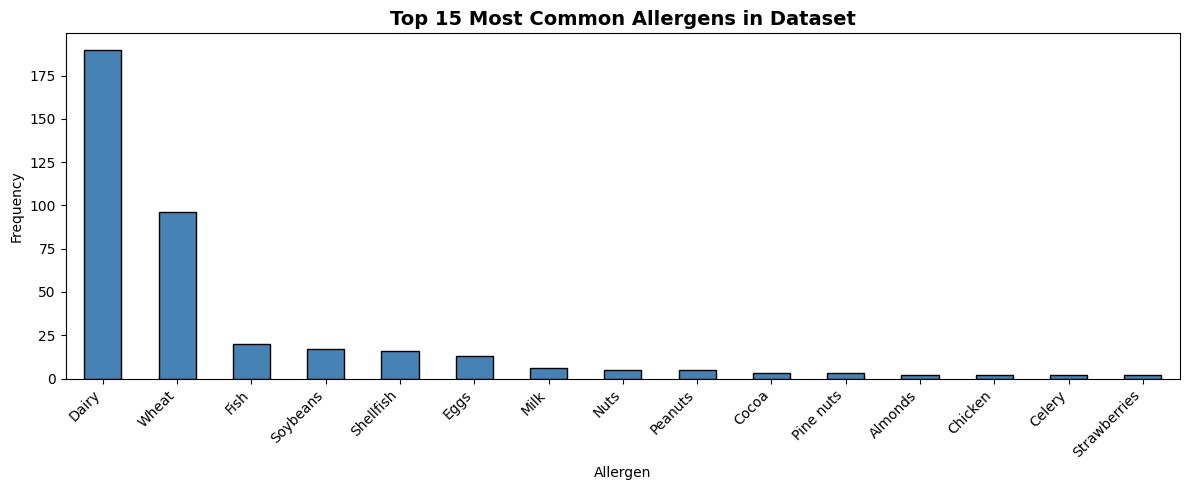

In [6]:
# Most common allergens
allergen_list = df['Allergens'].dropna().str.split(', ').explode()
allergen_counts = allergen_list.value_counts().head(15)

plt.figure(figsize=(12, 5))
allergen_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Most Common Allergens in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Allergen')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('allergen_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  Step 3: Data Preprocessing & Feature Engineering

In [7]:
import re

# ── 3.1 Drop empty / invalid rows ────────────────────────────────────────────
df = df[df['Prediction'].isin(['Contains', 'Does not contain'])].reset_index(drop=True)
print(f'Rows after cleaning: {len(df)}')

# ── 3.2 Fill missing text fields with 'none' ─────────────────────────────────
text_cols = ['Food Product', 'Main Ingredient', 'Sweetener', 'Fat/Oil', 'Seasoning', 'Allergens']
for col in text_cols:
    df[col] = df[col].fillna('none').astype(str).str.strip().str.lower()

# ── 3.3 Combine ALL text columns into ONE rich text feature ──────────────────
# This is the KEY feature engineering step — NLP model reads full ingredient context
df['combined_text'] = (
    'food: '      + df['Food Product']    + ' | ' +
    'ingredient: '+ df['Main Ingredient'] + ' | ' +
    'sweetener: ' + df['Sweetener']       + ' | ' +
    'fat: '       + df['Fat/Oil']         + ' | ' +
    'seasoning: ' + df['Seasoning']       + ' | ' +
    'allergens: ' + df['Allergens']
)

# ── 3.4 Clean text ────────────────────────────────────────────────────────────
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9|: ,]', ' ', text)  # keep alphanumeric and delimiters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['combined_text'] = df['combined_text'].apply(clean_text)

# ── 3.5 Encode target label ───────────────────────────────────────────────────
# Contains = 1 (unsafe), Does not contain = 0 (safe)
df['label'] = (df['Prediction'] == 'Contains').astype(int)

print('\nSample combined text:')
print(df['combined_text'].iloc[0])
print('\nLabel distribution:')
print(df['label'].value_counts())
df[['combined_text', 'label']].head(5)

Rows after cleaning: 398

Sample combined text:
food: almond cookies | ingredient: almonds | sweetener: sugar | fat: butter | seasoning: flour | allergens: almonds, wheat, dairy

Label distribution:
label
1    255
0    143
Name: count, dtype: int64


,combined_text,label
0,food: almond cookies | ingredient: almonds | s...,1
1,food: almond cookies | ingredient: almonds | s...,1
2,food: chicken noodle soup | ingredient: chicke...,1
3,food: chicken noodle soup | ingredient: chicke...,1
4,food: cheddar cheese | ingredient: cheese | sw...,1


In [8]:
# ── 3.6 Train / Validation / Test Split ──────────────────────────────────────
X = np.array(df['combined_text'].tolist())
y = np.array(df['label'].tolist())

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'Train size : {len(X_train)}')
print(f'Val size   : {len(X_val)}')
print(f'Test size  : {len(X_test)}')

Train size : 278
Val size   : 60
Test size  : 60


---
##  Step 4: Model 1 — Bidirectional LSTM (Deep Learning)

**Concepts used:** Tokenization → Word Embeddings → BiLSTM → Dense Classifier

In [9]:
# ── 4.1 Tokenization & Padding ───────────────────────────────────────────────
VOCAB_SIZE  = 3000   # unique tokens in our small vocabulary
MAX_LEN     = 50     # max tokens per sample
EMBED_DIM   = 64     # word embedding dimension

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert text → sequences of token IDs
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad all sequences to same length
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Vocabulary size   : {len(tokenizer.word_index)}')
print(f'Training shape    : {X_train_pad.shape}')
print(f'\nSample token IDs  : {X_train_pad[0][:15]}')

Vocabulary size   : 354
Training shape    : (278, 50)

Sample token IDs  : [  4 180 118   5 147   6   2   7  10   3 118 181 119   8   2]


In [10]:
# ── 4.2 Build BiLSTM Model ────────────────────────────────────────────────────
def build_bilstm_model(vocab_size, embed_dim, max_len):
    model = Sequential([
        # Layer 1: Embedding — converts token IDs → dense vectors (vector embeddings)
        Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=max_len,
                  name='word_embeddings'),
        Dropout(0.3),

        # Layer 2: Bidirectional LSTM — reads sequence in both directions
        Bidirectional(LSTM(128, return_sequences=True, dropout=0.3,
                           recurrent_dropout=0.2), name='bilstm_1'),

        # Layer 3: Second Bidirectional LSTM — deeper representation
        Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.2), name='bilstm_2'),

        # Layer 4: Dense layers for classification
        BatchNormalization(),
        Dense(128, activation='relu', name='dense_1'),
        Dropout(0.4),
        Dense(64, activation='relu', name='dense_2'),
        Dropout(0.3),

        # Output: sigmoid for binary classification
        Dense(1, activation='sigmoid', name='output')
    ])
    return model

lstm_model = build_bilstm_model(VOCAB_SIZE, EMBED_DIM, MAX_LEN)
lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ word_embeddings (Embedding)     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
# ── 4.3 Train BiLSTM ──────────────────────────────────────────────────────────
early_stop = EarlyStopping(monitor='val_accuracy', patience=10,
                            restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=5, verbose=1, min_lr=1e-6)

history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=80,
    batch_size=16,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print('\n✅ BiLSTM Training complete!')

Epoch 1/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 154ms/step - accuracy: 0.5647 - loss: 0.6773 - val_accuracy: 0.6500 - val_loss: 0.6760 - learning_rate: 0.0010
Epoch 2/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.7806 - loss: 0.4942 - val_accuracy: 0.6500 - val_loss: 0.6095 - learning_rate: 0.0010
Epoch 3/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.9101 - loss: 0.2498 - val_accuracy: 0.8500 - val_loss: 0.5321 - learning_rate: 0.0010
Epoch 4/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.9640 - loss: 0.1294 - val_accuracy: 0.8000 - val_loss: 0.4157 - learning_rate: 0.0010
Epoch 5/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.9820 - loss: 0.0825 - val_accuracy: 0.8333 - val_loss: 0.3650 - learning_rate: 0.0010
Epoch 6/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.9748 - loss: 0.0819 - val_accuracy: 0.8667 - val_loss: 0.3145 - learning_rate: 0.0010
Epoch 7/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.9964 - loss: 0.0395 - val

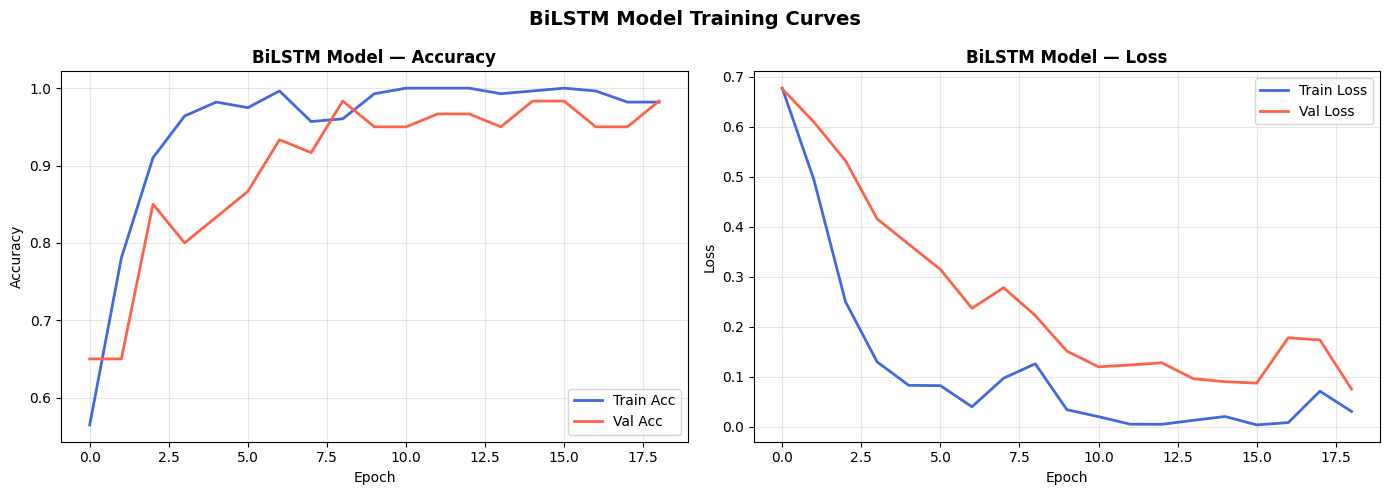

In [12]:
# ── 4.4 Plot Training History ─────────────────────────────────────────────────
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'],     label='Train Acc', color='royalblue', lw=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Acc',   color='tomato',    lw=2)
    axes[0].set_title(f'{model_name} — Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train Loss', color='royalblue', lw=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='tomato',    lw=2)
    axes[1].set_title(f'{model_name} — Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle(f'{model_name} Training Curves', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ","_")}_training.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history_lstm, 'BiLSTM Model')

In [13]:
# ── 4.5 Evaluate BiLSTM on Test Set ──────────────────────────────────────────
y_pred_lstm_prob = lstm_model.predict(X_test_pad)
y_pred_lstm      = (y_pred_lstm_prob > 0.5).astype(int).flatten()

lstm_acc = accuracy_score(y_test, y_pred_lstm)
print(f'\n📊 BiLSTM Test Accuracy: {lstm_acc*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lstm,
                             target_names=['Does Not Contain', 'Contains']))

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 834ms/step

📊 BiLSTM Test Accuracy: 85.00%

Classification Report:
                  precision    recall  f1-score   support

Does Not Contain       1.00      0.59      0.74        22
        Contains       0.81      1.00      0.89        38

        accuracy                           0.85        60
       macro avg       0.90      0.80      0.82        60
    weighted avg       0.88      0.85      0.84        60



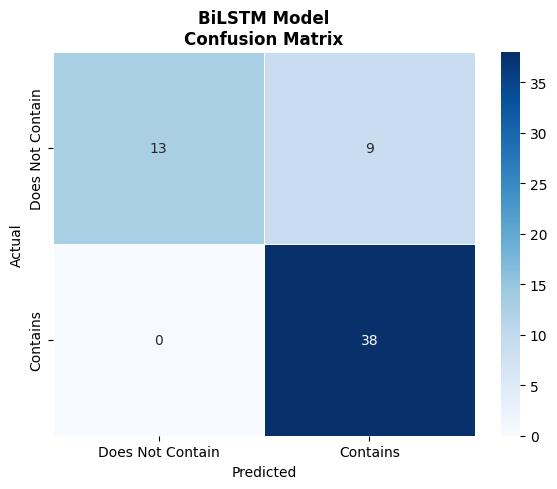

In [14]:
# ── 4.6 Confusion Matrix ──────────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Does Not Contain', 'Contains'],
                yticklabels=['Does Not Contain', 'Contains'],
                linewidths=0.5)
    plt.title(f'{title}\nConfusion Matrix', fontweight='bold')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}_cm.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_confusion_matrix(y_test, y_pred_lstm, 'BiLSTM Model')

---
##  Step 5: Model 2 — DistilBERT Fine-Tuning (Transformer)

**Concepts used:** Pre-trained Transformer → Tokenization → Vector Embeddings → Fine-tuning → Binary Classification

> DistilBERT is a lighter, faster version of BERT — perfect for small datasets.

In [15]:
# ── 5.1 Load DistilBERT Tokenizer ─────────────────────────────────────────────
BERT_MODEL_NAME = 'distilbert-base-uncased'
bert_tokenizer  = DistilBertTokenizer.from_pretrained(BERT_MODEL_NAME)

print(f'✅ Loaded tokenizer: {BERT_MODEL_NAME}')

# Show how BERT tokenizes a sample sentence
sample = X_train[0]
tokens = bert_tokenizer.tokenize(sample[:100])
print(f'\nSample text    : {sample[:80]}...')
print(f'BERT tokens    : {tokens[:20]}...')

✅ Loaded tokenizer: distilbert-base-uncased

Sample text    : food: vada pav | ingredient: potato | sweetener: none | fat: oil | seasoning: pa...
BERT tokens    : ['food', ':', 'va', '##da', 'pa', '##v', '|', 'ingredient', ':', 'potato', '|', 'sweet', '##ener', ':', 'none', '|', 'fat', ':', 'oil', '|']...


In [16]:
# ── 5.2 Create PyTorch Dataset ────────────────────────────────────────────────
class FoodSafetyDataset(TorchDataset):
    """
    Custom PyTorch Dataset.
    Tokenizes text and returns input_ids, attention_mask, and label.
    """
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'labels'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

BERT_MAX_LEN = 64

train_dataset = FoodSafetyDataset(X_train, y_train, bert_tokenizer, BERT_MAX_LEN)
val_dataset   = FoodSafetyDataset(X_val,   y_val,   bert_tokenizer, BERT_MAX_LEN)
test_dataset  = FoodSafetyDataset(X_test,  y_test,  bert_tokenizer, BERT_MAX_LEN)

print(f'Train dataset size : {len(train_dataset)}')
print(f'Val dataset size   : {len(val_dataset)}')
print(f'Test dataset size  : {len(test_dataset)}')

# Show one sample from dataset
sample_item = train_dataset[0]
print(f'\nSample input_ids shape  : {sample_item["input_ids"].shape}')
print(f'Sample attention_mask   : {sample_item["attention_mask"][:10]}...')
print(f'Sample label            : {sample_item["labels"]}')

Train dataset size : 278
Val dataset size   : 60
Test dataset size  : 60

Sample input_ids shape  : torch.Size([64])
Sample attention_mask   : tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])...
Sample label            : 0


In [17]:
# ── 5.3 Load DistilBERT Model for Sequence Classification ─────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

bert_model = DistilBertForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=2,          # binary: Contains / Does Not Contain
    ignore_mismatched_sizes=True
)
bert_model.to(device)
print('\n✅ DistilBERT model loaded!')
total_params = sum(p.numel() for p in bert_model.parameters())
print(f'Total parameters: {total_params:,}')

Using device: cpu


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 19981.44it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✅ DistilBERT model loaded!
Total parameters: 66,955,010


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1  = f1_score(labels, predictions, average='weighted')
    return {'accuracy': acc, 'f1': f1}

training_args = TrainingArguments(
    output_dir                  = './bert_results',
    num_train_epochs            = 15,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size  = 8,
    warmup_steps                = 50,
    weight_decay                = 0.01,
    learning_rate               = 2e-5,
    eval_strategy               = 'epoch',    
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'accuracy',
    logging_steps               = 10,         
    report_to                   = 'none',
    seed                        = 42
)

trainer = Trainer(
    model             = bert_model,
    args              = training_args,
    train_dataset     = train_dataset,
    eval_dataset      = val_dataset,
    compute_metrics   = compute_metrics,
    processing_class  = bert_tokenizer 
)

print('✅ Trainer configured!')

✅ Trainer configured!


In [ ]:
# ── 5.7 Fine-Tune DistilBERT ──────────────────────────────────────────────────
print(' Starting DistilBERT fine-tuning...')
trainer.train()
print('\n DistilBERT fine-tuning complete!')

🚀 Starting DistilBERT fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.582515,0.373154,0.950000,0.950667
2,0.015898,0.230668,0.950000,0.950667
3,0.005198,0.275549,0.950000,0.950667
4,0.003302,0.297768,0.950000,0.950667
5,0.002214,0.312894,0.950000,0.950667
6,0.001821,0.323497,0.950000,0.950667
7,0.001471,0.334050,0.950000,0.950667
8,0.001123,0.342134,0.950000,0.950667
9,0.001104,0.348667,0.950000,0.950667
10,0.000950,0.354098,0.950000,0.950667


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.68it/s]



✅ DistilBERT fine-tuning complete!



📊 DistilBERT Test Accuracy: 96.67%

Classification Report:
                  precision    recall  f1-score   support

Does Not Contain       0.92      1.00      0.96        22
        Contains       1.00      0.95      0.97        38

        accuracy                           0.97        60
       macro avg       0.96      0.97      0.96        60
    weighted avg       0.97      0.97      0.97        60



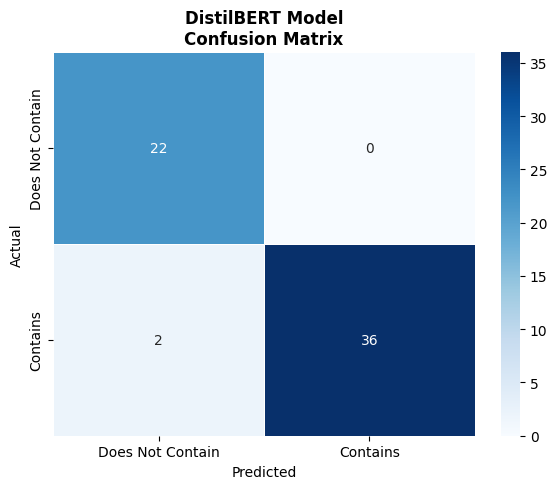

In [23]:
# ── 5.8 Evaluate DistilBERT on Test Set ───────────────────────────────────────
bert_predictions = trainer.predict(test_dataset)
y_pred_bert = np.argmax(bert_predictions.predictions, axis=-1)

bert_acc = accuracy_score(y_test, y_pred_bert)
print(f'\n📊 DistilBERT Test Accuracy: {bert_acc*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_bert,
                             target_names=['Does Not Contain', 'Contains']))

plot_confusion_matrix(y_test, y_pred_bert, 'DistilBERT Model')

---
##  Step 6: Model Comparison & Final Results

In [24]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Collect all metrics
results = {
    'Model': ['BiLSTM', 'DistilBERT (Fine-tuned)'],
    'Test Accuracy': [
        round(accuracy_score(y_test, y_pred_lstm)  * 100, 2),
        round(accuracy_score(y_test, y_pred_bert)  * 100, 2),
    ],
    'F1 Score': [
        round(f1_score(y_test, y_pred_lstm, average='weighted') * 100, 2),
        round(f1_score(y_test, y_pred_bert, average='weighted') * 100, 2),
    ],
    'Precision': [
        round(precision_score(y_test, y_pred_lstm, average='weighted') * 100, 2),
        round(precision_score(y_test, y_pred_bert, average='weighted') * 100, 2),
    ],
    'Recall': [
        round(recall_score(y_test, y_pred_lstm, average='weighted') * 100, 2),
        round(recall_score(y_test, y_pred_bert, average='weighted') * 100, 2),
    ]
}

results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')
print('\n' + '='*60)
print('         📊 FINAL MODEL COMPARISON RESULTS')
print('='*60)
print(results_df.to_string())
print('='*60)


         📊 FINAL MODEL COMPARISON RESULTS
                         Test Accuracy  F1 Score  Precision  Recall
Model                                                              
BiLSTM                           85.00     83.87      87.87   85.00
DistilBERT (Fine-tuned)          96.67     96.69      96.94   96.67


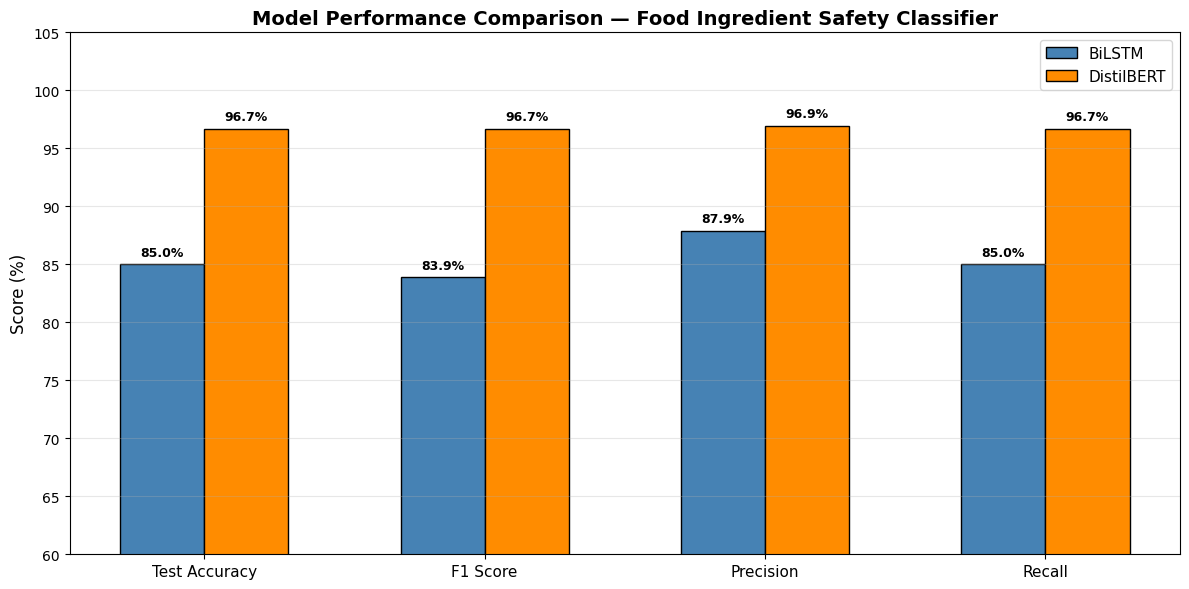

✅ Plot saved as model_comparison.png


In [25]:
# Visualize comparison
metrics = ['Test Accuracy', 'F1 Score', 'Precision', 'Recall']
x      = np.arange(len(metrics))
width  = 0.3

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, results_df.loc['BiLSTM', metrics],
               width, label='BiLSTM', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, results_df.loc['DistilBERT (Fine-tuned)', metrics],
               width, label='DistilBERT', color='darkorange', edgecolor='black')

ax.set_ylim(60, 105)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Performance Comparison — Food Ingredient Safety Classifier',
             fontsize=14, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved as model_comparison.png')

---
##  Step 7: Predict on New Input (Live Demo)

In [28]:
# ── BiLSTM Prediction Function ────────────────────────────────────────────────
def predict_lstm(food_product, main_ingredient, sweetener='none',
                  fat_oil='none', seasoning='none', allergens='none'):
    text = (
        f'food: {food_product} | ingredient: {main_ingredient} | '
        f'sweetener: {sweetener} | fat: {fat_oil} | '
        f'seasoning: {seasoning} | allergens: {allergens}'
    ).lower()
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob = lstm_model.predict(pad, verbose=0)[0][0]
    label = 'Contains Allergen ⚠️' if prob > 0.5 else 'Safe — No Allergen ✅'
    return label, round(float(prob) * 100, 2)


# ── DistilBERT Prediction Function ────────────────────────────────────────────
def predict_bert(food_product, main_ingredient, sweetener='none',
                  fat_oil='none', seasoning='none', allergens='none'):
    text = (
        f'food: {food_product} | ingredient: {main_ingredient} | '
        f'sweetener: {sweetener} | fat: {fat_oil} | '
        f'seasoning: {seasoning} | allergens: {allergens}'
    ).lower()
    enc = bert_tokenizer(
        text, max_length=BERT_MAX_LEN, padding='max_length',
        truncation=True, return_tensors='pt'
    )
    bert_model.eval()
    with torch.no_grad():
        out    = bert_model(**{k: v.to(device) for k, v in enc.items()})
        probs  = torch.softmax(out.logits, dim=-1).cpu().numpy()[0]
        pred   = np.argmax(probs)
    label = 'Contains Allergen ⚠️' if pred == 1 else 'Safe — No Allergen ✅'
    return label, round(float(probs[pred]) * 100, 2)


# ── Test Predictions ──────────────────────────────────────────────────────────
test_samples = [
    dict(food_product='Almond Cake',     main_ingredient='almonds',
         sweetener='sugar', fat_oil='butter', seasoning='flour',
         allergens='almonds, wheat, dairy'),
    dict(food_product='Plain Rice',      main_ingredient='rice',
         sweetener='none',  fat_oil='none',   seasoning='salt',
         allergens='none'),
    dict(food_product='Peanut Butter',   main_ingredient='peanuts',
         sweetener='none',  fat_oil='palm oil', seasoning='salt',
         allergens='peanuts'),
    dict(food_product='Vegetable Soup',  main_ingredient='carrots',
         sweetener='none',  fat_oil='olive oil', seasoning='pepper',
         allergens='none'),
]

print('\n' + '='*70)
print('              LIVE PREDICTION DEMO')
print('='*70)
for s in test_samples:
    l_label, l_conf = predict_lstm(**s)
    b_label, b_conf = predict_bert(**s)
    print(f"\nFood     : {s['food_product']}")
    print(f"Allergens: {s['allergens']}")
    print(f"  BiLSTM    → {l_label}  (confidence: {l_conf}%)")
    print(f"  DistilBERT→ {b_label}  (confidence: {b_conf}%)")
print('\n' + '='*70)


              LIVE PREDICTION DEMO

Food     : Almond Cake
Allergens: almonds, wheat, dairy
  BiLSTM    → Contains Allergen ⚠️  (confidence: 97.42%)
  DistilBERT→ Contains Allergen ⚠️  (confidence: 79.1%)

Food     : Plain Rice
Allergens: none
  BiLSTM    → Safe — No Allergen ✅  (confidence: 38.92%)
  DistilBERT→ Safe — No Allergen ✅  (confidence: 63.89%)

Food     : Peanut Butter
Allergens: peanuts
  BiLSTM    → Contains Allergen ⚠️  (confidence: 90.03%)
  DistilBERT→ Contains Allergen ⚠️  (confidence: 71.92%)

Food     : Vegetable Soup
Allergens: none
  BiLSTM    → Safe — No Allergen ✅  (confidence: 28.99%)
  DistilBERT→ Safe — No Allergen ✅  (confidence: 64.14%)



---
##  Step 8: Save Models

In [27]:
import pickle, os

# Save BiLSTM model
lstm_model.save('bilstm_food_safety.keras')
with open('lstm_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print('✅ BiLSTM model saved as bilstm_food_safety.keras')
print('✅ Tokenizer saved as lstm_tokenizer.pkl')

# Save DistilBERT model
os.makedirs('distilbert_food_safety', exist_ok=True)
bert_model.save_pretrained('distilbert_food_safety')
bert_tokenizer.save_pretrained('distilbert_food_safety')
print('✅ DistilBERT model saved in distilbert_food_safety/')

✅ BiLSTM model saved as bilstm_food_safety.keras
✅ Tokenizer saved as lstm_tokenizer.pkl


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.71it/s]

✅ DistilBERT model saved in distilbert_food_safety/


---
## ✅ Project Summary

| Item | Detail |
|------|--------|
| **Dataset** | Food Ingredients & Allergens (398 samples) |
| **Task** | Binary Classification: Contains Allergen / Safe |
| **Model 1** | Bidirectional LSTM with Embedding + BatchNorm |
| **Model 2** | DistilBERT fine-tuned (Hugging Face Transformers) |
| **Key Concepts** | Tokenization, Vector Embeddings, Transformer, LSTM, Fine-Tuning |
| **Framework** | TensorFlow/Keras + PyTorch + Hugging Face |

### Key Techniques Demonstrated:
- **Tokenization** — converting raw text to token IDs (both Keras Tokenizer & BERT Tokenizer)
- **Word Embeddings** — dense vector representations of words (Embedding layer)
- **Bidirectional LSTM** — sequence learning in both directions
- **Transformer Architecture** — DistilBERT attention-based model
- **Transfer Learning / Fine-Tuning** — adapting pre-trained BERT to our domain
- **Feature Engineering** — combining multiple text columns into rich input
- **EarlyStopping & LR Scheduling** — preventing overfitting on small dataset